# 00 - Przygotowanie danych: ImageNet-1k

**Praca magisterska:** *„Analiza wpływu zakłóceń i perturbacji obrazów na stabilność reprezentacji generowanych przez głębokie sieci neuronowe, z uwzględnieniem klas obiektów"*

---

Notebook realizuje trzy zadania:

1. Pobranie zbioru walidacyjnego ImageNet-1k (50 000 obrazów, 1 000 klas) z repozytorium Hugging Face.
2. Budowę tablicy mapowań etykiet łączącej indeksy HuggingFace (0-999) z identyfikatorami synsetów WordNet - niezbędnej do poprawnej ewaluacji pretrenowanych modeli.
3. Zapis plików referencyjnych na Google Drive do katalogu `mgr_266484/data/`, stanowiących wejście dla notebooków 01-04.

Pełny ImageNet-1k val zastępuje wcześniej używany podzbiór `clane9/imagenet-100`, eliminując ograniczenia związane z niereprezentywną selekcją klas i umożliwiając obliczenie standardowej metryki mCE (mean Corruption Error) porównywalnej z literaturą.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q datasets huggingface_hub

In [ ]:
import os, json, urllib.request, random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset, DownloadConfig, VerificationMode
from huggingface_hub import login

random.seed(42)
np.random.seed(42)

In [ ]:
# ── ścieżki ───────────────────────────────────────────────────────────────────
ROOT         = '/content/drive/MyDrive/mgr_266484'
DATA_DIR     = f'{ROOT}/data'
BASELINE_DIR = f'{ROOT}/baseline'
RESULTS_DIR  = f'{ROOT}/results'
FIGURES_DIR  = f'{ROOT}/figures'

# ── modele ────────────────────────────────────────────────────────────────────
from torchvision import models

MODELS = {
    'resnet50':  lambda: models.resnet50 (weights=models.ResNet50_Weights.IMAGENET1K_V2),
    'resnet101': lambda: models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2),
    'resnet152': lambda: models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2),
    'vit_b_32':  lambda: models.vit_b_32 (weights=models.ViT_B_32_Weights.IMAGENET1K_V1),
    'vit_b_16':  lambda: models.vit_b_16 (weights=models.ViT_B_16_Weights.IMAGENET1K_V1),
    'vit_l_16':  lambda: models.vit_l_16 (weights=models.ViT_L_16_Weights.IMAGENET1K_V1),
}

BATCH_SIZES = {
    'resnet50': 256, 'resnet101': 128, 'resnet152': 128,
    'vit_b_32': 128, 'vit_b_16':   64, 'vit_l_16':   32,
}

# ── zakłócenia ────────────────────────────────────────────────────────────────
CORRUPTIONS = {
    'noise':   ['gaussian_noise', 'shot_noise', 'impulse_noise'],
    'blur':    ['defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur'],
    'weather': ['snow', 'frost', 'fog', 'brightness'],
    'digital': ['contrast', 'elastic_transform', 'pixelate', 'jpeg_compression'],
}
SEVERITIES        = [1, 2, 3, 4, 5]
ALL_CORRUPTIONS   = [c for lst in CORRUPTIONS.values() for c in lst]
CORRUPTION_TO_CAT = {c: cat for cat, lst in CORRUPTIONS.items() for c in lst}

SEED = 42
import os
for d in [ROOT, DATA_DIR, BASELINE_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)
print('Struktura folderów:')
for d in [ROOT, DATA_DIR, BASELINE_DIR, RESULTS_DIR, FIGURES_DIR]:
    print(f'  {d}')

Struktura folderów:
  /content/drive/MyDrive/mgr_266484
  /content/drive/MyDrive/mgr_266484/data
  /content/drive/MyDrive/mgr_266484/baseline
  /content/drive/MyDrive/mgr_266484/results
  /content/drive/MyDrive/mgr_266484/figures


## 1. Logowanie do HuggingFace

Dostęp do `imagenet-1k` wymaga zaakceptowania licencji na stronie datasetu
(https://huggingface.co/datasets/imagenet-1k) oraz tokena Read wygenerowanego
w ustawieniach konta (https://huggingface.co/settings/tokens).


In [ ]:
login()

## 2. Pobranie zbioru

Pobierany jest wyłącznie split walidacyjny (50 000 obrazów). Biblioteka `datasets`
cache'uje dane w `~/.cache/huggingface/`, co eliminuje narzut sieciowy przy
kolejnych uruchomieniach w tej samej sesji Colab.


In [ ]:
os.environ['HF_DATASETS_CACHE'] = '/content/drive/MyDrive/mgr_266484/hf_cache'

ds_val = load_dataset(
    'ILSVRC/imagenet-1k',
    split='validation',
    data_files={'validation': 'data/validation-*'},
    verification_mode=VerificationMode.NO_CHECKS)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

data/validation-00000-of-00014.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

data/validation-00001-of-00014.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/validation-00002-of-00014.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

data/validation-00010-of-00014.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

data/validation-00011-of-00014.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/validation-00012-of-00014.parquet:   0%|          | 0.00/493M [00:00<?, ?B/s]

data/validation-00013-of-00014.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/50000 [00:00<?, ? examples/s]

## 3. Mapowanie etykiet

W ImageNet-1k etykiety HuggingFace (0–999) są tożsame z indeksami klas modeli
torchvision — nie jest wymagane dodatkowe mapowanie indeksów. Niezbędne jest
natomiast mapowanie `imagenet1k_idx ↔ wnid`, potrzebne do analizy per-klasa
w notebooku 04.

Plik `imagenet_class_index.json` jest standardowym artefaktem dystrybuowanym
z torchvision i zawiera dla każdego indeksu: identyfikator synsetu WordNet
oraz nazwę klasy.


In [ ]:
IMAGENET1K_JSON = '/content/imagenet_class_index.json'
if not os.path.exists(IMAGENET1K_JSON):
    urllib.request.urlretrieve(
        'https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json',
        IMAGENET1K_JSON)

with open(IMAGENET1K_JSON) as f:
    raw = json.load(f)

idx_to_wnid = {int(k): v[0] for k, v in raw.items()}
idx_to_name = {int(k): v[1] for k, v in raw.items()}

sample_lbl = ds_val[0]['label']
assert sample_lbl in idx_to_name, 'Etykiety HF niezgodne z imagenet_class_index!'
print(f'Weryfikacja OK. Przykład: label={sample_lbl} → {idx_to_name[sample_lbl]}')

Weryfikacja OK. Przykład: label=91 → coucal


In [ ]:
label_map = pd.DataFrame([
    {'imagenet1k_label': idx, 'wnid': idx_to_wnid[idx], 'class_name': idx_to_name[idx]}
    for idx in range(1000)
])
label_map.to_csv(f'{DATA_DIR}/label_map.csv', index=False)

import shutil
shutil.copy(IMAGENET1K_JSON, f'{DATA_DIR}/imagenet_class_index.json')

print(f'Zapisano: {DATA_DIR}/label_map.csv  ({len(label_map)} wierszy)')
print(f'Zapisano: {DATA_DIR}/imagenet_class_index.json')
label_map.head(8)

Zapisano: /content/drive/MyDrive/mgr_266484/data/label_map.csv  (1000 wierszy)
Zapisano: /content/drive/MyDrive/mgr_266484/data/imagenet_class_index.json


,imagenet1k_label,wnid,class_name
0,0,n01440764,tench
1,1,n01443537,goldfish
2,2,n01484850,great_white_shark
3,3,n01491361,tiger_shark
4,4,n01494475,hammerhead
5,5,n01496331,electric_ray
6,6,n01498041,stingray
7,7,n01514668,cock


## 4. Weryfikacja semantyczna mapowania

Porównanie nazw klas z `imagenet_class_index.json` z nazwami wbudowanymi
w obiekt `ds_val.features['label'].names`. Niezgodność wskazywałaby na błąd
w jednym ze źródeł lub w pipeline'ie ładowania.


In [ ]:
hf_names = ds_val.features['label'].names
mismatches = []
for idx, row in label_map.iterrows():
    hf  = hf_names[row['imagenet1k_label']].lower().replace('_', ' ')
    our = row['class_name'].lower().replace('_', ' ')
    if hf != our:
        mismatches.append({'idx': idx, 'hf': hf_names[row['imagenet1k_label']], 'ours': row['class_name']})

if not mismatches:
    print('✓ Wszystkie 1000 nazw klas zgodne między HuggingFace a imagenet_class_index.json.')
else:
    print(f'Znaleziono {len(mismatches)} niezgodności (drobne różnice leksykalne są akceptowalne):')
    for m in mismatches[:10]:
        print(f'  idx={m["idx"]}: HF="{m["hf"]}" vs ours="{m["ours"]}"')

Znaleziono 493 niezgodności (drobne różnice leksykalne są akceptowalne):
  idx=0: HF="tench, Tinca tinca" vs ours="tench"
  idx=1: HF="goldfish, Carassius auratus" vs ours="goldfish"
  idx=2: HF="great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias" vs ours="great_white_shark"
  idx=3: HF="tiger shark, Galeocerdo cuvieri" vs ours="tiger_shark"
  idx=4: HF="hammerhead, hammerhead shark" vs ours="hammerhead"
  idx=5: HF="electric ray, crampfish, numbfish, torpedo" vs ours="electric_ray"
  idx=9: HF="ostrich, Struthio camelus" vs ours="ostrich"
  idx=10: HF="brambling, Fringilla montifringilla" vs ours="brambling"
  idx=11: HF="goldfinch, Carduelis carduelis" vs ours="goldfinch"
  idx=12: HF="house finch, linnet, Carpodacus mexicanus" vs ours="house_finch"


## 5. Statystyki zbioru

In [ ]:
from collections import Counter

counts   = Counter(ds_val['label'])
counts_s = pd.Series(counts).sort_index()
print('Rozkład obrazów per klasa:')
print(f'  min:  {counts_s.min()}')
print(f'  max:  {counts_s.max()}')
print(f'  mean: {counts_s.mean():.1f}')
if counts_s.min() == counts_s.max():
    print(f'\n✓ Zbiór idealnie zbalansowany: {counts_s.min()} obrazów per klasa.')

Rozkład obrazów per klasa:
  min:  50
  max:  50
  mean: 50.0

✓ Zbiór idealnie zbalansowany: 50 obrazów per klasa.


In [ ]:
sample_idxs = random.sample(range(len(ds_val)), 300)
sizes = [ds_val[i]['image'].size for i in sample_idxs]
widths, heights = zip(*sizes)
shorter = [min(w,h) for w,h in sizes]

print('Rozdzielczość (próbka n=300):')
print(f'  krótszy bok - min: {min(shorter)}, max: {max(shorter)}, mean: {sum(shorter)/len(shorter):.0f}')
upscale = 256 / (sum(shorter)/len(shorter))
print(f'  średni współczynnik upskalingu Resize(256): {upscale:.2f}×')

Rozdzielczość (próbka n=300):
  krótszy bok - min: 90, max: 1635, mean: 392
  średni współczynnik upskalingu Resize(256): 0.65×


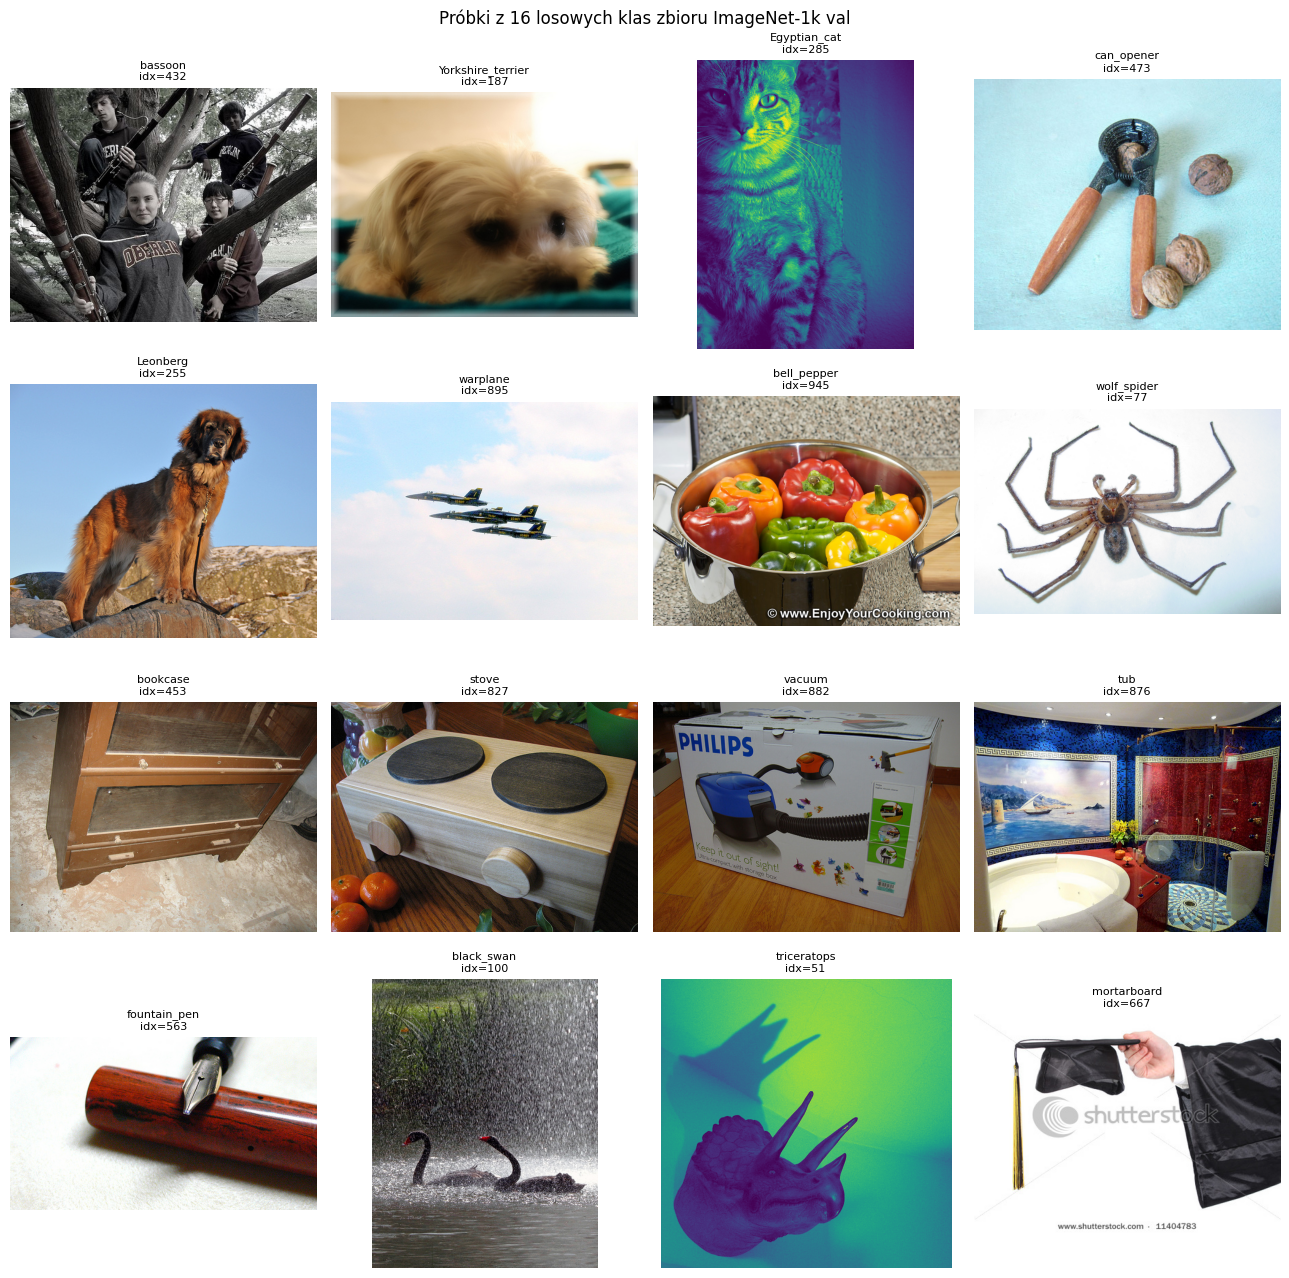

In [ ]:
sample_classes = random.sample(range(1000), 16)
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for ax, cls in zip(axes.flat, sample_classes):
    for i in range(len(ds_val)):
        if ds_val[i]['label'] == cls:
            ax.imshow(ds_val[i]['image'])
            ax.set_title(f'{idx_to_name[cls][:25]}\nidx={cls}', fontsize=8)
            ax.axis('off')
            break
fig.suptitle('Próbki z 16 losowych klas zbioru ImageNet-1k val', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/00_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()